In [45]:
import pandas as pd

In [46]:
dataset = pd.read_csv("final_cleaned_data.csv")

In [47]:
dataset.head()

,Unnamed: 0,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_amount
0,0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [48]:
dataset["InvoiceDate"] = pd.to_datetime(dataset["InvoiceDate"], errors='coerce')


#  TOP 10 Product By Qunatity ssale:-

In [49]:
tops_quantity_sale = (dataset.groupby('Description')['Quantity']
                      .sum()
                      .sort_values(ascending= False)
                      .head(10)
                      )

tops_quantity_sale

Description
WHITE HANGING HEART T-LIGHT HOLDER    56915
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54754
BROCADE RING PURSE                    48166
PACK OF 72 RETRO SPOT CAKE CASES      45156
ASSORTED COLOUR BIRD ORNAMENT         44551
60 TEATIME FAIRY CAKE CASES           35806
PACK OF 60 PINK PAISLEY CAKE CASES    31006
JUMBO BAG RED RETROSPOT               29578
SMALL POPCORN HOLDER                  25718
BLACK AND WHITE PAISLEY FLOWER MUG    25685
Name: Quantity, dtype: int64

#  Top 10 Product by Revnue

In [50]:
top_revnue_sale = (
    dataset.groupby('Description')['Total_amount']
    .sum()
    .sort_values(ascending = False)
    .head(10)
)

top_revnue_sale

Description
WHITE HANGING HEART T-LIGHT HOLDER     151624.31
REGENCY CAKESTAND 3 TIER               143893.35
Manual                                  98560.64
ASSORTED COLOUR BIRD ORNAMENT           70493.83
JUMBO BAG RED RETROSPOT                 51759.30
POSTAGE                                 48741.08
ROTATING SILVER ANGELS T-LIGHT HLDR     40186.65
PAPER CHAIN KIT 50'S CHRISTMAS          36933.50
PARTY BUNTING                           35035.90
EDWARDIAN PARASOL NATURAL               34044.75
Name: Total_amount, dtype: float64


# Top 10 Customer by spendings:-

In [51]:
top_customer_spend = (
    dataset.groupby('Customer ID')["Total_amount"]
    .sum()
    .sort_values(ascending = False)
    .head(10)
    
)
top_customer_spend

Customer ID
18102.0    349164.35
14646.0    248396.50
14156.0    196566.74
14911.0    152147.57
13694.0    131443.19
17511.0     84541.17
15061.0     83284.38
16684.0     80489.21
16754.0     65500.07
17949.0     60117.60
Name: Total_amount, dtype: float64

#  order per customer :- 


In [52]:
order_per_customer = dataset.groupby('Customer ID')["Invoice"].nunique()
order_per_customer

Customer ID
12346.0    11
12347.0     2
12348.0     1
12349.0     3
12351.0     1
           ..
18283.0     6
18284.0     1
18285.0     1
18286.0     2
18287.0     4
Name: Invoice, Length: 4312, dtype: int64

#  Country analysis:-

In [53]:
country_sales = dataset.groupby('Country')["Total_amount"].sum().sort_values(ascending = False).head(10)

In [54]:
country_sales

Country
United Kingdom    7414755.963
EIRE               356085.210
Netherlands        268786.000
Germany            202395.321
France             146215.420
Sweden              53171.390
Denmark             50906.850
Spain               47601.420
Switzerland         43921.390
Australia           31446.800
Name: Total_amount, dtype: float64

#  Time based analysis:-

In [55]:
dataset["Year"] = dataset["InvoiceDate"].dt.year
dataset['Month'] = dataset["InvoiceDate"].dt.month
dataset["Day"] = dataset["InvoiceDate"].dt.day
dataset["Hour"] = dataset["InvoiceDate"].dt.hour

#  Monthly Sales Trend:-

In [56]:
monthly_sale = dataset.groupby(['Year' , 'Month'])["Total_amount"].sum()
monthly_sale

Year  Month
2009  12        686654.160
2010  1         557319.062
      2         506371.066
      3         699608.991
      4         594609.192
      5         599985.790
      6         639066.580
      7         591636.740
      8         604242.650
      9         831615.001
      10       1036680.000
      11       1172336.042
      12        311878.000
Name: Total_amount, dtype: float64

#  Visualization :- 

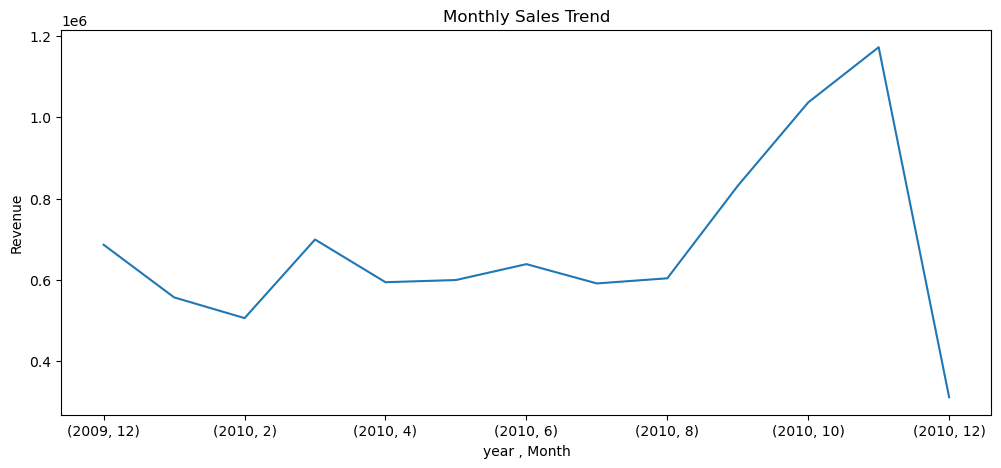

In [57]:
from matplotlib import pyplot as plt

monthly_sale.plot(figsize = (12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("year , Month")
plt.ylabel("Revenue")
plt.show()